# SIFT Part 3: Orientation Assignment

## The Problem: Rotation Invariance

Imagine you photograph a Sudoku puzzle, then rotate your phone 45°. The same corner should be detected and matched, but:

```
    Original          Rotated 45°
    ┌───                  ╱
    │                   ╱
    │                 ╱
```

If we describe the keypoint using the original pixel layout, the descriptions won't match!

## The Solution

1. Compute a **dominant orientation** for each keypoint based on local image gradients
2. Rotate the descriptor coordinate system to align with this orientation
3. Now the same feature looks the same regardless of image rotation!

This notebook shows how SIFT computes the orientation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# Import our previous functions
def gaussian_kernel_1d(sigma, size=None):
    if size is None:
        size = int(np.ceil(6 * sigma))
        if size % 2 == 0:
            size += 1
    x = np.arange(size) - size // 2
    kernel = np.exp(-x**2 / (2 * sigma**2))
    return kernel / kernel.sum()

def gaussian_blur(image, sigma):
    kernel = gaussian_kernel_1d(sigma)
    pad = len(kernel) // 2
    padded = np.pad(image, pad, mode='reflect')
    temp = np.zeros_like(padded, dtype=np.float64)
    for i in range(len(kernel)):
        temp[:, pad:-pad] += kernel[i] * padded[:, i:i+image.shape[1]]
    result = np.zeros_like(image, dtype=np.float64)
    for i in range(len(kernel)):
        result += kernel[i] * temp[i:i+image.shape[0], pad:-pad]
    return result

In [2]:
# Load test image
examples_path = Path('../../Examples')
test_images = list(examples_path.glob('*.jpg')) + list(examples_path.glob('*.png'))

if test_images:
    img = cv2.imread(str(test_images[0]), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (400, 400))
else:
    img = np.ones((400, 400), dtype=np.uint8) * 255
    for i in range(0, 401, 44):
        img[i:i+2, :] = 0
        img[:, i:i+2] = 0

img_float = img.astype(np.float64) / 255.0
print(f"Image shape: {img.shape}")

Image shape: (400, 400)


## 1. Image Gradients: The Foundation

### What Are Gradients?

A gradient tells us:
- **Magnitude**: How fast intensity changes (edge strength)
- **Direction**: Which way intensity increases (edge orientation)

### Computing Gradients

$$m(x,y) = \sqrt{(L(x+1,y) - L(x-1,y))^2 + (L(x,y+1) - L(x,y-1))^2}$$

$$\theta(x,y) = \arctan\left(\frac{L(x,y+1) - L(x,y-1)}{L(x+1,y) - L(x-1,y)}\right)$$

Where:
- $L$ = Gaussian-blurred image (at the keypoint's scale)
- $m$ = gradient magnitude
- $\theta$ = gradient direction (0° to 360°)

In [3]:
def compute_gradients(image):
    """
    Compute gradient magnitude and orientation for every pixel.
    
    Returns:
        magnitude: 2D array of gradient magnitudes
        orientation: 2D array of gradient angles in degrees [0, 360)
    """
    # Compute derivatives using central differences
    # dx = L(x+1, y) - L(x-1, y)
    dx = np.zeros_like(image)
    dx[:, 1:-1] = image[:, 2:] - image[:, :-2]
    
    # dy = L(x, y+1) - L(x, y-1)
    dy = np.zeros_like(image)
    dy[1:-1, :] = image[2:, :] - image[:-2, :]
    
    # Magnitude
    magnitude = np.sqrt(dx**2 + dy**2)
    
    # Orientation (convert to degrees, range [0, 360))
    orientation = np.rad2deg(np.arctan2(dy, dx)) % 360
    
    return magnitude, orientation

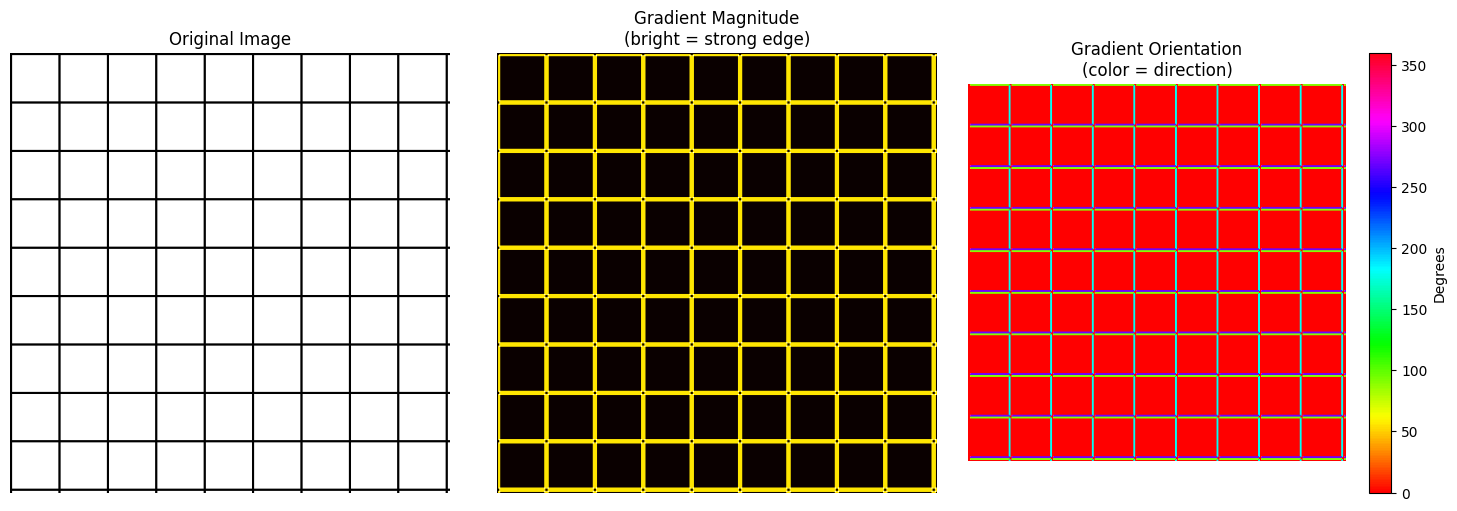

In [4]:
# Compute and visualize gradients
magnitude, orientation = compute_gradients(img_float)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(magnitude, cmap='hot')
axes[1].set_title('Gradient Magnitude\n(bright = strong edge)')
axes[1].axis('off')

# Use HSV colormap for orientation (cyclic)
im = axes[2].imshow(orientation, cmap='hsv', vmin=0, vmax=360)
axes[2].set_title('Gradient Orientation\n(color = direction)')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], label='Degrees')

plt.tight_layout()
plt.show()

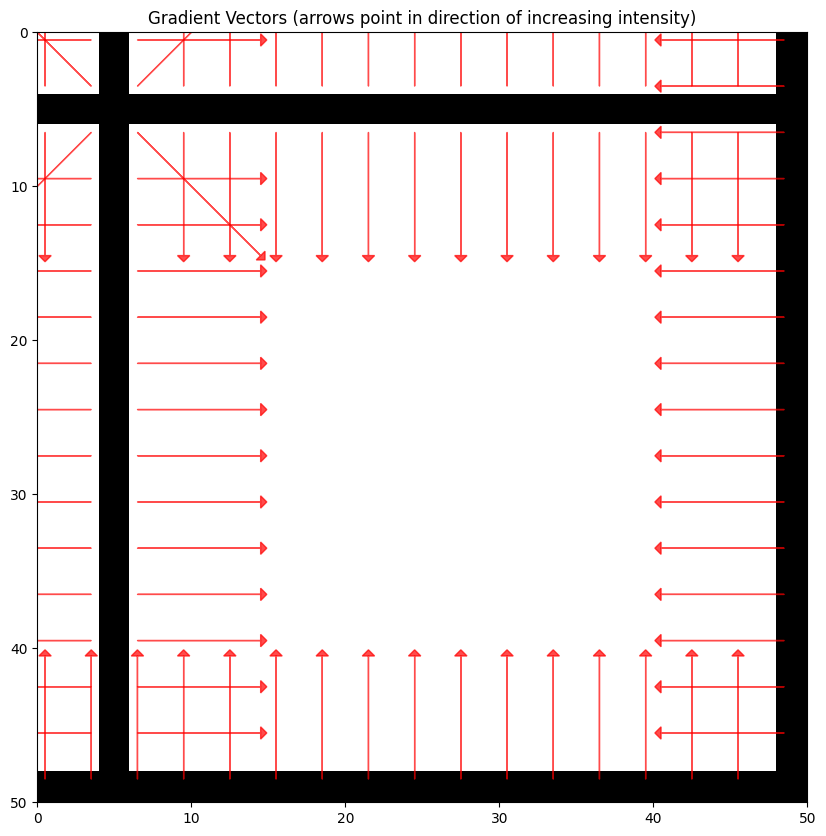

In [5]:
# Visualize gradients as arrows in a small region
fig, ax = plt.subplots(figsize=(10, 10))

# Pick a region with interesting features
y_start, x_start = 40, 40
region_size = 50

region = img_float[y_start:y_start+region_size, x_start:x_start+region_size]
mag_region = magnitude[y_start:y_start+region_size, x_start:x_start+region_size]
ori_region = orientation[y_start:y_start+region_size, x_start:x_start+region_size]

ax.imshow(region, cmap='gray', extent=[0, region_size, region_size, 0])

# Draw gradient arrows (subsample for clarity)
step = 3
for y in range(0, region_size, step):
    for x in range(0, region_size, step):
        m = mag_region[y, x]
        if m > 0.01:  # Only show significant gradients
            theta = np.deg2rad(ori_region[y, x])
            # Arrow length proportional to magnitude
            arrow_len = m * 8
            dx = arrow_len * np.cos(theta)
            dy = arrow_len * np.sin(theta)
            ax.arrow(x + 0.5, y + 0.5, dx, dy, 
                     head_width=0.8, head_length=0.4,
                     fc='red', ec='red', alpha=0.7)

ax.set_title('Gradient Vectors (arrows point in direction of increasing intensity)', fontsize=12)
ax.set_xlim(0, region_size)
ax.set_ylim(region_size, 0)
plt.show()

## 2. Orientation Histogram

### The Key Idea

For each keypoint, we:
1. Look at gradients in a **circular window** around the keypoint
2. Build a **histogram of orientations** (36 bins = 10° each)
3. Weight each gradient by:
   - Its magnitude (strong gradients count more)
   - A Gaussian centered on the keypoint (closer gradients count more)

### Why 36 Bins?

- 360° / 36 = 10° per bin
- Fine enough to get accurate orientation
- Coarse enough to be noise-resistant

### The Gaussian Weighting

We use $\sigma = 1.5 \times \sigma_{keypoint}$ for the weighting window:
- Keypoints at larger scales use larger windows
- Scale-invariant orientation computation!

In [6]:
def compute_orientation_histogram(magnitude, orientation, kp_x, kp_y, sigma, 
                                   num_bins=36, window_factor=1.5):
    """
    Compute orientation histogram for a keypoint.
    
    Args:
        magnitude: Gradient magnitude image
        orientation: Gradient orientation image (degrees)
        kp_x, kp_y: Keypoint location
        sigma: Keypoint scale (determines window size)
        num_bins: Number of orientation bins (default 36 = 10° each)
        window_factor: Gaussian window sigma = window_factor * sigma
    
    Returns:
        histogram: 1D array of orientation counts
    """
    height, width = magnitude.shape
    
    # Window radius: 3 * window_sigma captures most of the Gaussian
    window_sigma = window_factor * sigma
    radius = int(round(3 * window_sigma))
    
    # Initialize histogram
    histogram = np.zeros(num_bins)
    bin_width = 360.0 / num_bins
    
    # Integer keypoint location
    kp_x_int = int(round(kp_x))
    kp_y_int = int(round(kp_y))
    
    # Iterate over window
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            y = kp_y_int + dy
            x = kp_x_int + dx
            
            # Check bounds
            if x < 0 or x >= width or y < 0 or y >= height:
                continue
            
            # Check if within circular window
            dist_sq = dx**2 + dy**2
            if dist_sq > radius**2:
                continue
            
            # Gaussian weight (closer to keypoint = higher weight)
            gaussian_weight = np.exp(-dist_sq / (2 * window_sigma**2))
            
            # Contribution = magnitude * gaussian weight
            weight = magnitude[y, x] * gaussian_weight
            
            # Determine bin
            angle = orientation[y, x]
            bin_idx = int(angle / bin_width) % num_bins
            
            # Add to histogram
            histogram[bin_idx] += weight
    
    return histogram

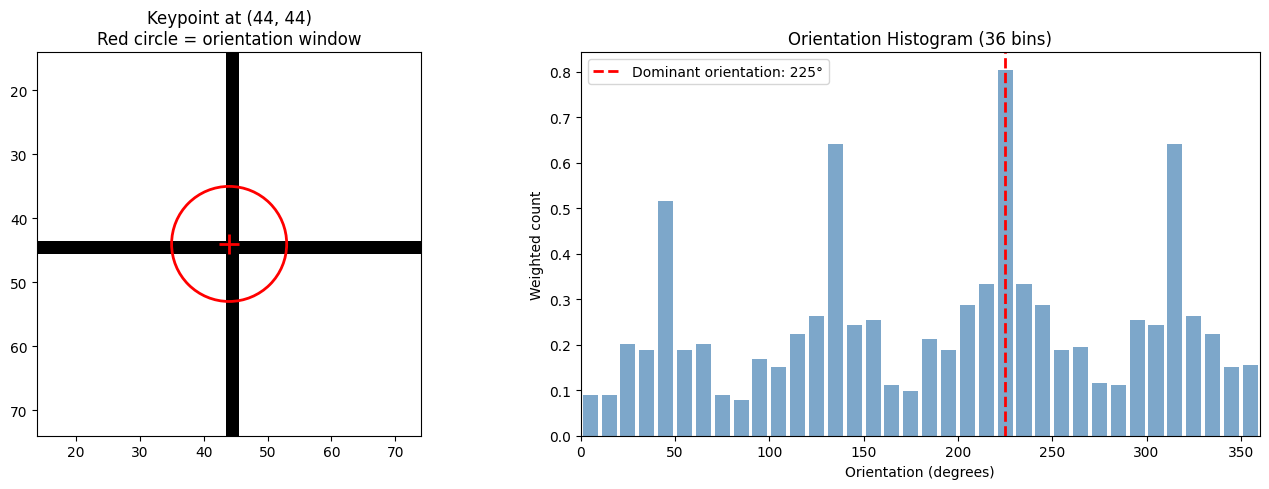

Dominant orientation: 225°


In [7]:
# Compute histogram for a sample keypoint
# Pick a point near a corner
kp_x, kp_y = 44, 44  # Near a grid intersection
sigma = 2.0

# Use blurred image at keypoint's scale
img_blurred = gaussian_blur(img_float, sigma)
mag, ori = compute_gradients(img_blurred)

histogram = compute_orientation_histogram(mag, ori, kp_x, kp_y, sigma)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: show keypoint location and window
axes[0].imshow(img, cmap='gray')
circle = plt.Circle((kp_x, kp_y), 3 * 1.5 * sigma, fill=False, color='red', linewidth=2)
axes[0].add_patch(circle)
axes[0].plot(kp_x, kp_y, 'r+', markersize=15, markeredgewidth=2)
axes[0].set_title(f'Keypoint at ({kp_x}, {kp_y})\nRed circle = orientation window')
axes[0].set_xlim(kp_x - 30, kp_x + 30)
axes[0].set_ylim(kp_y + 30, kp_y - 30)

# Right: histogram
bin_centers = np.arange(0, 360, 10) + 5  # Center of each 10° bin
axes[1].bar(bin_centers, histogram, width=8, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Orientation (degrees)')
axes[1].set_ylabel('Weighted count')
axes[1].set_title('Orientation Histogram (36 bins)')
axes[1].set_xlim(0, 360)

# Mark the peak
peak_bin = np.argmax(histogram)
peak_angle = peak_bin * 10 + 5
axes[1].axvline(peak_angle, color='red', linestyle='--', linewidth=2,
                label=f'Dominant orientation: {peak_angle}°')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Dominant orientation: {peak_angle}°")

## 3. Finding the Peak (with Sub-Bin Accuracy)

### Why Refine the Peak?

Our bins are 10° wide. If the true orientation is 47°, the peak might be at bin 4 (40-50°). We can do better!

### Parabolic Interpolation

Fit a parabola through the peak and its neighbors:

```
     histogram values
            *
         *     *
       *    ↑    *
            └── True peak (between bins)
```

The refined peak position:

$$\hat{p} = p + \frac{h_{p-1} - h_{p+1}}{2(h_{p-1} - 2h_p + h_{p+1})}$$

Where $p$ is the peak bin index and $h$ are histogram values.

In [8]:
def find_dominant_orientations(histogram, peak_ratio=0.8):
    """
    Find dominant orientations from histogram.
    
    SIFT creates multiple keypoints if there are multiple peaks
    above 80% of the maximum. This improves matching stability.
    
    Args:
        histogram: Orientation histogram
        peak_ratio: Minimum ratio of max to be considered a peak
    
    Returns:
        List of refined orientations (in degrees)
    """
    num_bins = len(histogram)
    bin_width = 360.0 / num_bins
    
    # Smooth histogram to reduce noise
    # Simple smoothing: average with neighbors
    smoothed = np.zeros_like(histogram)
    for i in range(num_bins):
        smoothed[i] = (histogram[(i-1) % num_bins] + 
                       histogram[i] + 
                       histogram[(i+1) % num_bins]) / 3
    
    # Find peaks
    max_val = smoothed.max()
    threshold = peak_ratio * max_val
    
    orientations = []
    
    for i in range(num_bins):
        # Check if this bin is a local maximum above threshold
        prev_val = smoothed[(i - 1) % num_bins]
        curr_val = smoothed[i]
        next_val = smoothed[(i + 1) % num_bins]
        
        if curr_val > prev_val and curr_val > next_val and curr_val >= threshold:
            # Parabolic interpolation for sub-bin accuracy
            # offset = (left - right) / (2 * (left - 2*center + right))
            denominator = 2 * (prev_val - 2 * curr_val + next_val)
            
            if abs(denominator) > 1e-6:
                offset = (prev_val - next_val) / denominator
            else:
                offset = 0
            
            # Refined orientation
            orientation = (i + offset) * bin_width
            orientation = orientation % 360  # Wrap to [0, 360)
            
            orientations.append(orientation)
    
    return orientations

In [9]:
# Find dominant orientations
orientations = find_dominant_orientations(histogram)

print(f"Found {len(orientations)} dominant orientation(s):")
for i, ori in enumerate(orientations):
    print(f"  {i+1}. {ori:.1f}°")

Found 1 dominant orientation(s):
  1. 220.0°


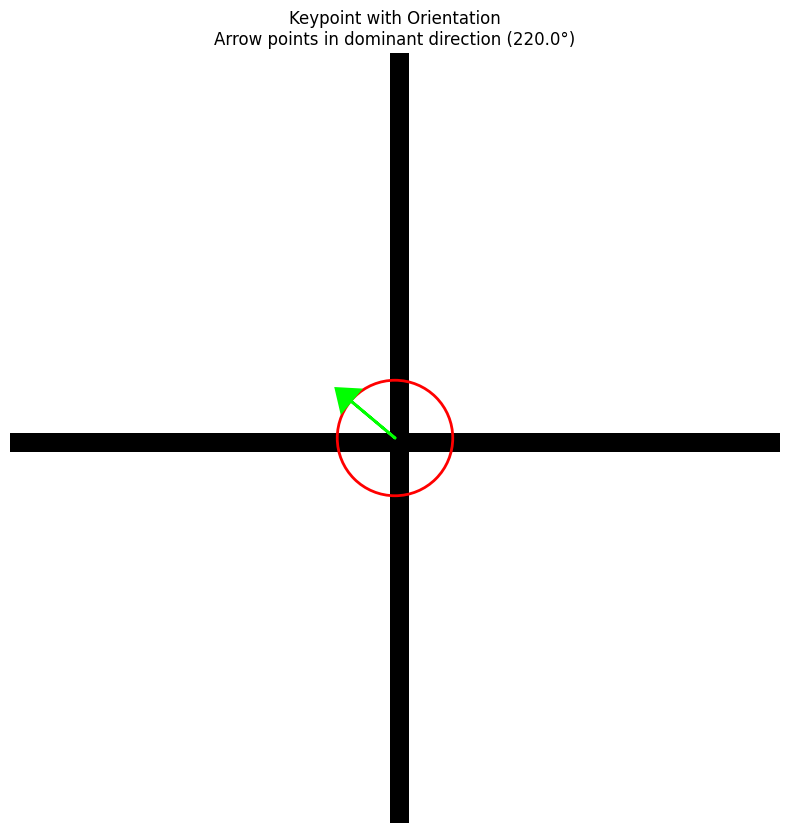

In [10]:
# Visualize the keypoint with its orientation
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(img, cmap='gray')

# Draw keypoint circle
radius = sigma * 3
circle = plt.Circle((kp_x, kp_y), radius, fill=False, color='red', linewidth=2)
ax.add_patch(circle)

# Draw orientation arrow(s)
for ori in orientations:
    theta = np.deg2rad(ori)
    arrow_len = radius
    dx = arrow_len * np.cos(theta)
    dy = arrow_len * np.sin(theta)
    ax.arrow(kp_x, kp_y, dx, dy,
             head_width=3, head_length=2,
             fc='lime', ec='lime', linewidth=2)

ax.set_title(f'Keypoint with Orientation\n'
             f'Arrow points in dominant direction ({orientations[0]:.1f}°)',
             fontsize=12)
ax.set_xlim(kp_x - 40, kp_x + 40)
ax.set_ylim(kp_y + 40, kp_y - 40)
ax.axis('off')
plt.show()

## 4. Complete Orientation Assignment

Now let's put it together with proper keypoint handling:

In [11]:
def assign_orientations(keypoints, gaussian_pyramid, sigmas):
    """
    Assign orientations to all keypoints.
    
    If a keypoint has multiple dominant orientations (>80% of max),
    create multiple keypoints at the same location with different orientations.
    
    Args:
        keypoints: List of keypoints with (x, y, octave, sigma, ...)
        gaussian_pyramid: List of blurred images per octave
        sigmas: Sigma values per scale per octave
    
    Returns:
        List of keypoints with added 'orientation' field
    """
    oriented_keypoints = []
    
    for kp in keypoints:
        octave = kp['octave']
        scale_idx = int(round(kp.get('scale_idx', 1)))
        
        # Clamp scale_idx to valid range
        scale_idx = max(0, min(scale_idx, len(gaussian_pyramid[octave]) - 1))
        
        # Get the Gaussian image at the keypoint's scale
        gaussian_image = gaussian_pyramid[octave][scale_idx]
        
        # Convert keypoint coordinates to octave coordinates
        scale_factor = 2 ** octave
        local_x = kp['x'] / scale_factor
        local_y = kp['y'] / scale_factor
        local_sigma = kp['sigma'] / scale_factor
        
        # Compute gradients
        mag, ori = compute_gradients(gaussian_image)
        
        # Build orientation histogram
        histogram = compute_orientation_histogram(
            mag, ori, local_x, local_y, local_sigma
        )
        
        # Find dominant orientations
        orientations = find_dominant_orientations(histogram)
        
        # Create keypoint(s) with orientation(s)
        for orientation in orientations:
            new_kp = kp.copy()
            new_kp['orientation'] = orientation
            oriented_keypoints.append(new_kp)
    
    return oriented_keypoints

In [12]:
# Create some sample keypoints for testing
# (In practice, these come from the keypoint detection in previous notebooks)

# Build Gaussian pyramid
def build_gaussian_pyramid(image, num_octaves=4, num_scales=5, sigma_base=1.6):
    s = num_scales - 3
    k = 2 ** (1 / s)
    pyramid = []
    sigmas_per_octave = []
    sigma_values = [sigma_base * (k ** i) for i in range(num_scales)]
    current_image = image.astype(np.float64)
    
    for octave in range(num_octaves):
        octave_images = []
        octave_sigmas = []
        for scale_idx, sigma in enumerate(sigma_values):
            if scale_idx == 0:
                blurred = gaussian_blur(current_image, sigma)
            else:
                sigma_prev = sigma_values[scale_idx - 1]
                sigma_diff = np.sqrt(max(0, sigma**2 - sigma_prev**2))
                if sigma_diff > 0:
                    blurred = gaussian_blur(octave_images[-1], sigma_diff)
                else:
                    blurred = octave_images[-1].copy()
            octave_images.append(blurred)
            octave_sigmas.append(sigma * (2 ** octave))
        pyramid.append(octave_images)
        sigmas_per_octave.append(octave_sigmas)
        if octave < num_octaves - 1:
            current_image = octave_images[s][::2, ::2]
    return pyramid, sigmas_per_octave

pyramid, sigmas = build_gaussian_pyramid(img_float, num_octaves=3, num_scales=5)

# Sample keypoints at grid corners
sample_keypoints = [
    {'x': 44, 'y': 44, 'octave': 0, 'scale_idx': 1, 'sigma': 2.0, 'response': 0.1},
    {'x': 88, 'y': 44, 'octave': 0, 'scale_idx': 1, 'sigma': 2.0, 'response': 0.1},
    {'x': 44, 'y': 88, 'octave': 0, 'scale_idx': 1, 'sigma': 2.0, 'response': 0.1},
    {'x': 88, 'y': 88, 'octave': 0, 'scale_idx': 1, 'sigma': 2.0, 'response': 0.1},
    {'x': 200, 'y': 200, 'octave': 0, 'scale_idx': 2, 'sigma': 3.2, 'response': 0.08},
]

# Assign orientations
oriented_kps = assign_orientations(sample_keypoints, pyramid, sigmas)

print(f"Input: {len(sample_keypoints)} keypoints")
print(f"Output: {len(oriented_kps)} oriented keypoints")
print(f"(Multiple if keypoint has multiple dominant orientations)")

Input: 5 keypoints
Output: 10 oriented keypoints
(Multiple if keypoint has multiple dominant orientations)


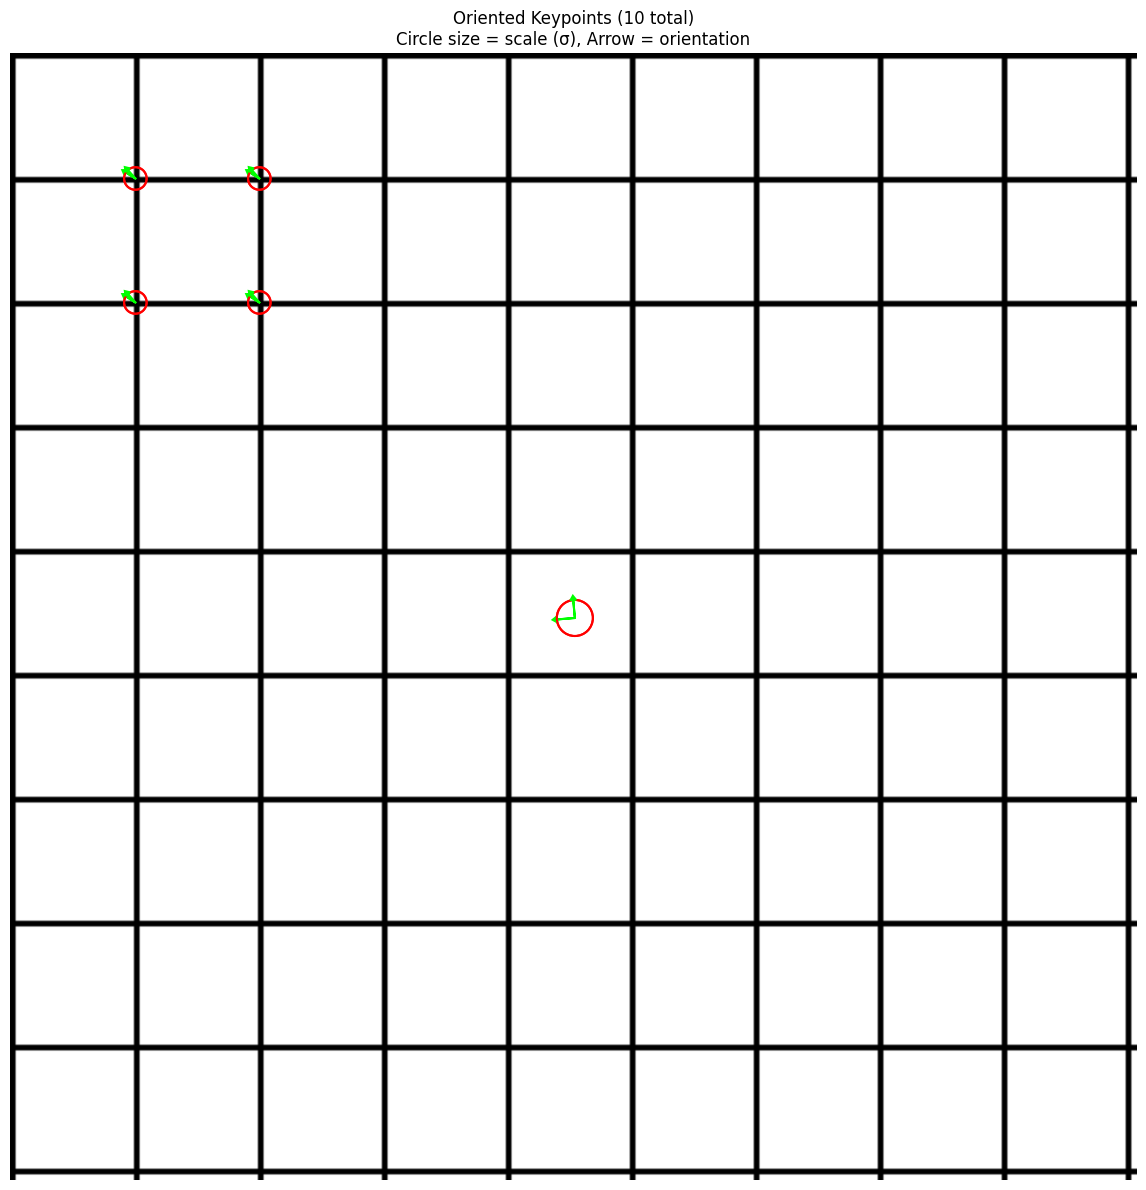

In [13]:
# Visualize all oriented keypoints
fig, ax = plt.subplots(figsize=(12, 12))

ax.imshow(img, cmap='gray')

for kp in oriented_kps:
    x, y = kp['x'], kp['y']
    sigma = kp['sigma']
    orientation = kp['orientation']
    
    # Draw circle
    radius = sigma * 2
    circle = plt.Circle((x, y), radius, fill=False, color='red', linewidth=1.5)
    ax.add_patch(circle)
    
    # Draw orientation arrow
    theta = np.deg2rad(orientation)
    dx = radius * np.cos(theta)
    dy = radius * np.sin(theta)
    ax.arrow(x, y, dx, dy,
             head_width=2, head_length=1.5,
             fc='lime', ec='lime', linewidth=1.5)

ax.set_title(f'Oriented Keypoints ({len(oriented_kps)} total)\n'
             f'Circle size = scale (σ), Arrow = orientation',
             fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Why Orientation Makes SIFT Rotation-Invariant

### The Key Insight

When we compute the descriptor (next notebook), we'll:
1. Rotate the sampling grid to align with the keypoint's orientation
2. Measure gradients **relative to this orientation**

### Example

```
Original Image                   Rotated 45°
                                 
    ↑ orientation = 90°             ↗ orientation = 135°
    │                               ╱
    ●                               ●
    
After alignment:                 After alignment:
    (rotate -90°)                   (rotate -135°)
    
    ●→                              ●→
    
Both now point RIGHT = Same canonical form!
```

### Result

The same physical feature produces the same descriptor regardless of image rotation.

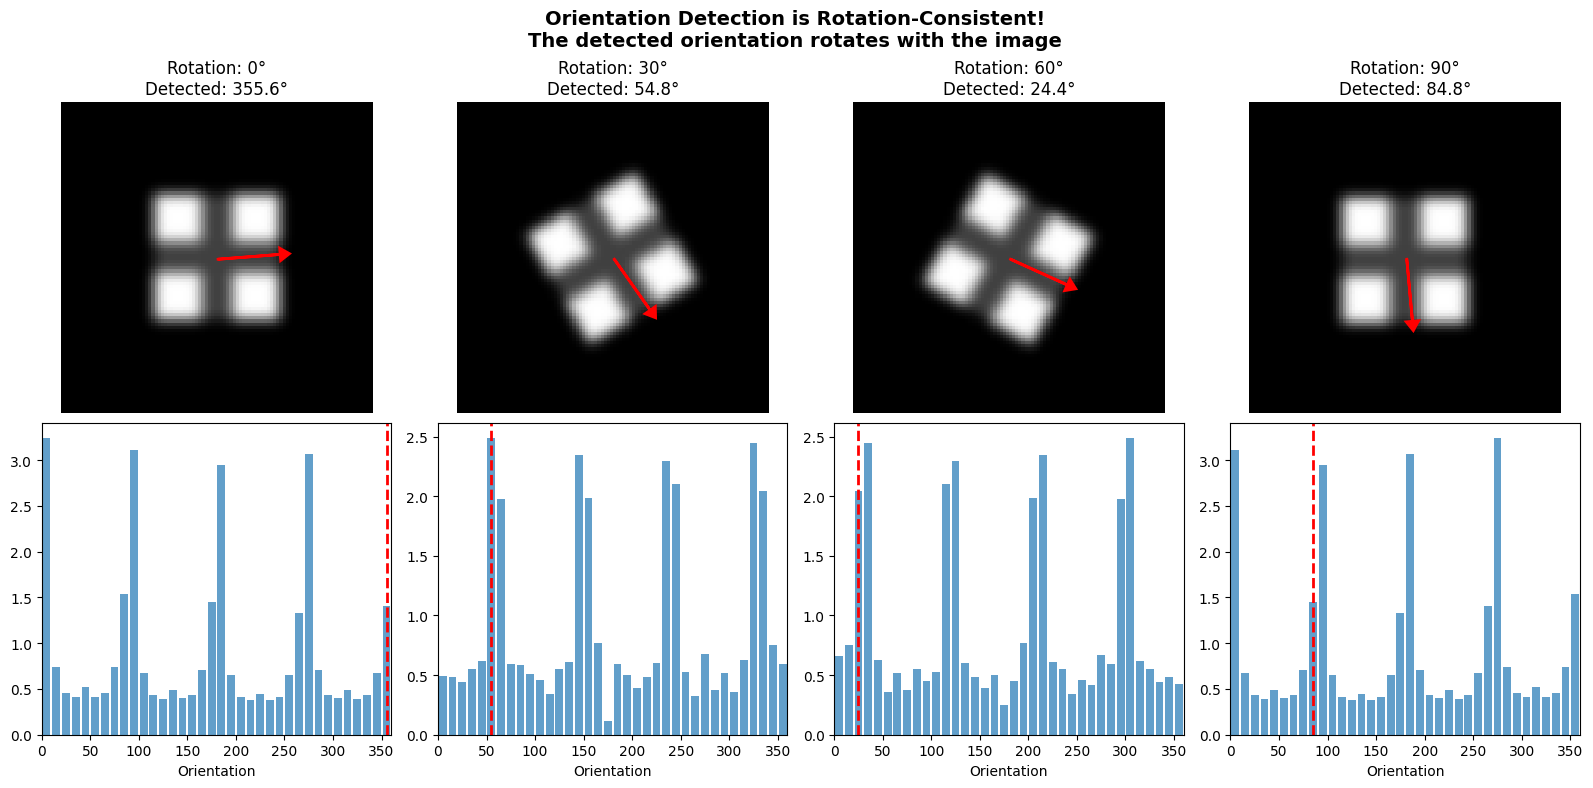

In [14]:
# Demonstrate rotation invariance
# Create a simple test pattern and rotate it

def rotate_image(image, angle_degrees, center=None):
    """Rotate image by angle_degrees around center."""
    if center is None:
        center = (image.shape[1] // 2, image.shape[0] // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle_degrees, 1.0)
    return cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))

# Create a distinctive corner pattern
pattern = np.zeros((100, 100), dtype=np.float64)
pattern[30:70, 30:70] = 0.8
pattern[45:55, 30:70] = 0.2
pattern[30:70, 45:55] = 0.2
pattern = gaussian_blur(pattern, 2)

# Rotate the pattern
angles = [0, 30, 60, 90]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, angle in enumerate(angles):
    rotated = rotate_image((pattern * 255).astype(np.uint8), angle) / 255.0
    
    # Compute orientation at center
    mag, ori = compute_gradients(rotated)
    hist = compute_orientation_histogram(mag, ori, 50, 50, 5)
    orientations = find_dominant_orientations(hist)
    
    # Top row: rotated image with detected orientation
    axes[0, i].imshow(rotated, cmap='gray')
    if orientations:
        theta = np.deg2rad(orientations[0])
        dx, dy = 20 * np.cos(theta), 20 * np.sin(theta)
        axes[0, i].arrow(50, 50, dx, dy, head_width=4, head_length=3,
                         fc='red', ec='red', linewidth=2)
    axes[0, i].set_title(f'Rotation: {angle}°\nDetected: {orientations[0]:.1f}°' if orientations else f'Rotation: {angle}°')
    axes[0, i].axis('off')
    
    # Bottom row: histogram
    bin_centers = np.arange(0, 360, 10) + 5
    axes[1, i].bar(bin_centers, hist, width=8, alpha=0.7)
    if orientations:
        axes[1, i].axvline(orientations[0], color='red', linestyle='--', linewidth=2)
    axes[1, i].set_xlim(0, 360)
    axes[1, i].set_xlabel('Orientation')

plt.suptitle('Orientation Detection is Rotation-Consistent!\n'
             'The detected orientation rotates with the image', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Summary

### What We Learned

1. **Gradients** describe local image structure:
   - Magnitude = edge strength
   - Orientation = edge direction

2. **Orientation Histogram** captures the dominant gradient directions around a keypoint:
   - 36 bins (10° each)
   - Weighted by magnitude and Gaussian distance
   - Scale-aware window size

3. **Peak Finding** with interpolation gives accurate orientation:
   - Find histogram peaks
   - Parabolic refinement for sub-bin accuracy
   - Multiple peaks → multiple keypoints

4. **Rotation Invariance** comes from:
   - Detecting a canonical orientation
   - Describing features relative to this orientation

### Next Steps (Notebook 04)

Now we have:
- **Where**: Keypoint location (x, y)
- **What scale**: Keypoint sigma (σ)
- **What orientation**: Dominant angle (θ)

Next: Create the actual **descriptor** - a 128-dimensional vector that describes the local appearance!

In [15]:
print("Functions created in this notebook:")
print("  - compute_gradients(image)")
print("  - compute_orientation_histogram(magnitude, orientation, kp_x, kp_y, sigma)")
print("  - find_dominant_orientations(histogram, peak_ratio)")
print("  - assign_orientations(keypoints, gaussian_pyramid, sigmas)")

Functions created in this notebook:
  - compute_gradients(image)
  - compute_orientation_histogram(magnitude, orientation, kp_x, kp_y, sigma)
  - find_dominant_orientations(histogram, peak_ratio)
  - assign_orientations(keypoints, gaussian_pyramid, sigmas)
